## Proyecto 1: Análisis de datos Airbnb de la Ciudad de México
### Preparación de datos

### Meta:
- Explorar los archivos de datos y crear un conjunto de datos para su posterior análisis.

### Contexto:
Para este proyecto se usaron los datos del sitio **Insideairbnb** de fecha 22 de marzo de 2021 para la Ciudad de México, se utilizaron los archivos Listing.csv y reviews.csv.

---
### Paso 1: Preparar entorno de trabajo.


In [ ]:
# Importar bibibliotecas necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
sns.set(style="whitegrid")
from datetime import datetime as dt
hoy = dt.today().strftime("%d-%m-%y")
print(hoy)

13-11-25


### Paso 2: Cargar y explorar los datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar datos y obtner tamaño del dataset
listings = pd.read_csv('/content/drive/MyDrive/GENTRIFICACION 2025/DATOS AIRBNB /BASE M/UNION_18C.csv')
listings.shape

(227088, 18)

In [ ]:
# Estructura del dataset
listings.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,14714,Private room c/ bathroom . Colonia Juarez.,57785,Diego,NaN,Cuauhtémoc,19.43035,-99.15511,Private room,478.0,2,0,NaN,NaN,2,327,NaN,NaN
1,22787,"Sunny suite w/ queen size bed, inside boutique...",87973,Diego,NaN,Cuauhtémoc,19.44076,-99.16324,Private room,1969.0,1,57,2019-05-27,0.52,9,355,NaN,NaN
2,33681,Couple of Rooms,145672,Edubiel,NaN,Tlalpan,19.27215,-99.21848,Private room,1740.0,1,0,NaN,NaN,1,365,NaN,NaN
3,35797,Villa Dante,153786,Dici,NaN,Cuajimalpa de Morelos,19.38399,-99.27335,Entire home/apt,3823.0,1,0,NaN,NaN,2,363,NaN,NaN
4,44616,CONDESA HAUS B&B,196253,Condesa Haus Bed & Breakfast CDMX,NaN,Cuauhtémoc,19.41006,-99.17645,Private room,1893.0,1,39,2019-05-02,0.42,10,334,NaN,NaN


In [ ]:
# Tipos de datos
listings.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,float64
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


In [ ]:
# más información del dataframe
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227088 entries, 0 to 227087
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              227088 non-null  int64  
 1   name                            227074 non-null  object 
 2   host_id                         227088 non-null  int64  
 3   host_name                       226159 non-null  object 
 4   neighbourhood_group             0 non-null       float64
 5   neighbourhood                   227088 non-null  object 
 6   latitude                        227088 non-null  float64
 7   longitude                       227088 non-null  float64
 8   room_type                       227088 non-null  object 
 9   price                           212042 non-null  float64
 10  minimum_nights                  227088 non-null  int64  
 11  number_of_reviews               227088 non-null  int64  
 12  last_review     

### Paso 3: Limpiar datos

In [ ]:
# Obtener valores NaNs
listings.isna().sum(axis=0)

,0
id,0
name,14
host_id,0
host_name,929
neighbourhood_group,227088
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,15046


In [ ]:
listings.drop(['id', 'neighbourhood_group','last_review', "license", "number_of_reviews_ltm"], axis=1, inplace=True)

Se eliminaron las columnas `id, neighbourhood_group y last_review` no son significativas para nuestro análisis.

Las colunma `last_review` nos dice que para ese mes no hubo revisión para el alojamiento y la columna review_per_month el NaN tomará un valor de 0 que al comparar con la columna number_of_review es cero. Finalmente `number_of_reviews_ltm` y `license` tienen valores nulos significativos.

In [ ]:
# Reemplazar los valores NaN en la columna reviews_per_month
listings.fillna({'reviews_per_month':0}, inplace=True)
listings.reviews_per_month.isnull().sum()

np.int64(0)

### Estadísticas descriptivas

In [ ]:
listings.describe()

,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,2.270880e+05,227088.000000,227088.000000,2.120420e+05,227088.000000,227088.000000,227088.000000,227088.000000,227088.000000
mean,2.009307e+08,19.403861,-99.167039,1.694114e+03,4.556432,41.505914,1.480799,13.927473,225.975371
std,1.766864e+08,0.042971,0.033591,1.290781e+04,24.189586,70.807904,1.913473,34.589137,130.282093
min,7.365000e+03,19.095762,-99.340820,0.000000e+00,1.000000,0.000000,0.000000,1.000000,0.000000
25%,4.905273e+07,19.388020,-99.179300,5.720000e+02,1.000000,2.000000,0.180000,1.000000,95.000000
50%,1.423187e+08,19.414420,-99.167820,9.660000e+02,2.000000,14.000000,0.900000,3.000000,267.000000
75%,3.366029e+08,19.431430,-99.154630,1.579000e+03,2.000000,50.000000,2.170000,10.000000,349.000000
max,7.031773e+08,19.565340,-98.962770,1.838000e+06,1125.000000,1342.000000,80.380000,292.000000,365.000000


### Eliminar valores atípicos
Se obsevó que las varibales  `price` y `minimum_nights` tienen valores atípicos.
- Para la columna precio el 75% de los valores estan por debajo de 1,579.00 (1,159 - 2021) pesos muy cerca de la media, pero hay un valor máximo de 1,838,000 (350,000.0 - 2021). pesos. Además esta columna tiene precios con valor cero lo que puede significar que no está disponible el alojamiento.
- Para la columna noches minimas el 75% de los valores estan por debajo de las 2 noches y hay un valor máximo de 1125..

<Axes: xlabel='price'>

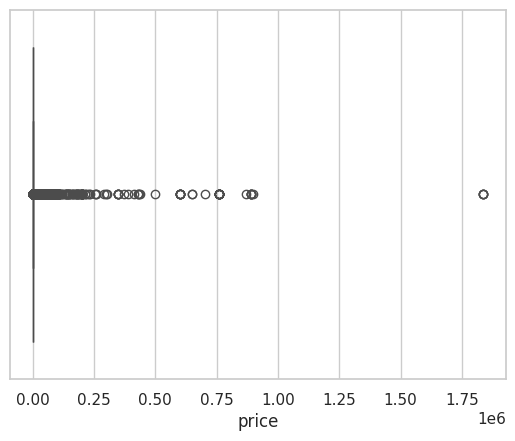

In [ ]:
sns.boxplot(x=listings['price'])

In [ ]:
# Filtrando valores atipicos
iqr = listings['price'].quantile(0.75) - listings['price'].quantile(0.25)
filtro_inferior = listings['price'] > listings['price'].quantile(0.25) - (iqr * 1.5)
filtro_superior = listings['price'] < listings['price'].quantile(0.75) + (iqr * 1.5)

listings_filtrado = listings[filtro_inferior & filtro_superior]

<Axes: xlabel='price'>

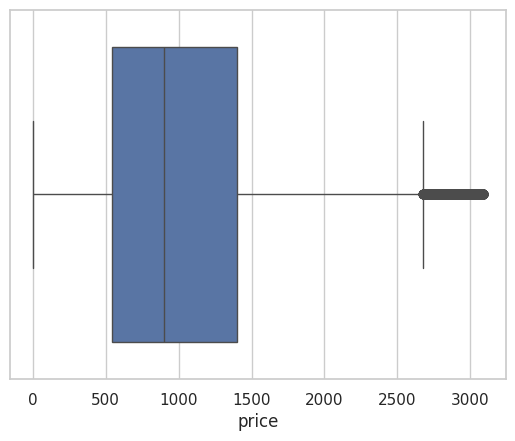

In [ ]:
# boxplot de datos filtrados
sns.boxplot(x=listings_filtrado['price'])

In [ ]:
#ELiminar los ceros de la columna de precios
mascara_ceros = (listings_filtrado['price'] > 0)
listings_filtrado[mascara_ceros].shape
listings_filtrado = listings_filtrado[mascara_ceros]
listings_filtrado.shape

(196077, 13)

<Axes: xlabel='price'>

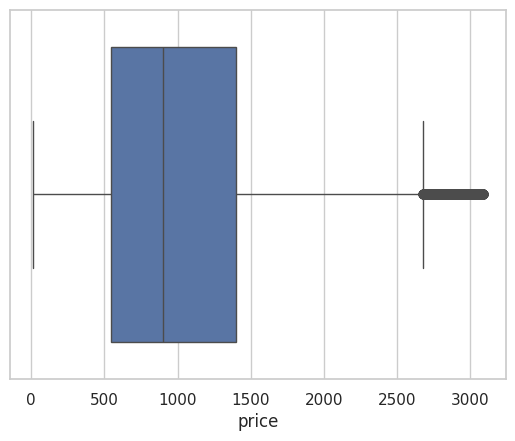

In [ ]:
# boxplot de datos sin los ceros
sns.boxplot(x=listings_filtrado['price'])

### Paso 4: Guardar los datos filtrados en un nuevo archivo.

In [ ]:
listings_filtrado.to_csv('listings_filtrado.csv', header = True, index = False)

## Conclusiones:
Al cargar el archivo se tenía 18 columnas con 227,088 observaciones y después de la limpieza y filtrado quedo un total de 13 de columnas y 196,077. Se eliminaron un total de 31,011 datos que significa el 13.65% de nuestros.